<a href="https://colab.research.google.com/github/UMB200/AI_ML_pytorch_projects/blob/main/09_pytorch_model_deployment_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09. PyTorch Model Deployment Exercises



### 1.0 Get various imports and helper functions

The code in the following cells prepares imports and data for the exercises below. They are taken from [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/).

In [1]:
import torch, torchvision, os, zipfile, random, requests, sys, pathlib
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
from timeit import default_timer as timer
import tqdm.auto as tqdm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from typing import List, Dict, Tuple
import pandas as pd
import gradio as gr
import shutil
from IPython.display import IFrame
from torch.utils.data import random_split
from collections import Counter


try:
  from torchinfo import summary
except:
  print("No torchinfo found, downloading")
  !pip install -q torchinfo
  from torchinfo import summary

if not os.path.exists('/content/helpers'):
  os.makedirs('/content/helpers')
  sys.path.insert(0, '/content/helpers')
helpers = Path('/content/helpers')

try:
  from helpers import predict, data_setup, set_rand_seed, download_data, engine, utils, vit
except:
  print(f"No helper scripts are found, downloading")
  !git clone https://github.com/UMB200/AI_ML_pytorch_projects.git
  !mv /content/AI_ML_pytorch_projects/helpers/* /content/helpers
  print(f"Remving extra stuff from: {helpers}")
  !rm -rf /content/AI_ML_pytorch_projects

  from helpers import predict, data_setup, set_rand_seed, download_data, engine, utils, vit


No torchinfo found, downloading
No helper scripts are found, downloading
Cloning into 'AI_ML_pytorch_projects'...
remote: Enumerating objects: 605, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 605 (delta 183), reused 130 (delta 130), pack-reused 410 (from 2)
Receiving objects: 100% (605/605), 46.50 MiB | 16.34 MiB/s, done.
Resolving deltas: 100% (330/330), done.
Remving extra stuff from: /content/helpers


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
#!rm helpers -rf

### 2.0 Get data



In [4]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data.download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                           destination="pizza_steak_sushi")
image_path

No data/pizza_steak_sushi dir is found, creating one


PosixPath('data/pizza_steak_sushi')

In [5]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

### 3.0 Preprocess data

Turn images into tensors using same code as PyTorch Paper Replicating section 2.1 and 2.2: https://www.learnpytorch.io/08_pytorch_paper_replicating/#21-prepare-transforms-for-images

In [6]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")



Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [7]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)
NUM_CLASSES = 3

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7c0274a7e030>,
 ['pizza', 'steak', 'sushi'])

In [8]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(0))

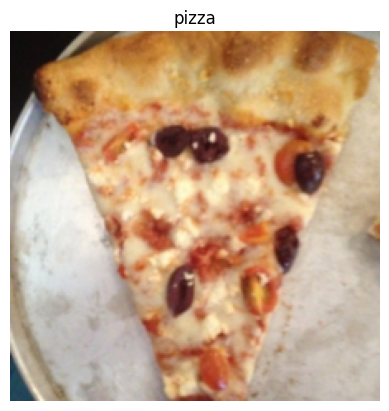

In [9]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

## Exercise 1. Make and time predictions with both feature extractor models on the test dataset using the GPU (`device="cuda"`).

* Compare the model's prediction times on GPU vs CPU - does this close the gap between them? As in, does making predictions on the GPU make the ViT feature extractor prediction times closer to the EffNetB2 feature extractor prediction times?
* You'll find code to do these steps in [section 5. Making predictions with our trained models and timing them](https://www.learnpytorch.io/09_pytorch_model_deployment/#5-making-predictions-with-our-trained-models-and-timing-them) and [section 6. Comparing model results, prediction times and size](https://www.learnpytorch.io/09_pytorch_model_deployment/#6-comparing-model-results-prediction-times-and-size).

### 1.1 EffNetB2 CPU-based prediction

In [10]:
# Create EffNetB2 model
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
effnetb2_transforms = effnetb2_weights.transforms()
effnetb2_model = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 233MB/s]


In [11]:
# Create EffnetB2 feature extractor
effnetb2_model_extracted = engine.feature_extractor(
    model=effnetb2_model,
    weights=effnetb2_weights,
    transform=effnetb2_transforms,
    dropout=0.3,
    model_name="EffNetB2",
    in_features=1408,
    out_features=NUM_CLASSES
)

Created new EffNetB2


In [12]:
# Function to run predictions on all data
test_data_path_list = list(test_dir.glob("*/*.jpg"))

def predict_store_average_resuls(
    paths: List[pathlib.Path],
    model: torch.nn.Module,
    transform: torchvision.transforms,
    class_names: List[str],
    device=device):

  prediction_list = []
  for path in tqdm(paths):
    iteration_prediction = {};
    iteration_prediction["image_path"] = path
    ground_truth_class_name = path.parent.stem
    iteration_prediction["ground_truth_class_name"] = ground_truth_class_name

    start_time = timer()
    img = Image.open(path)
    img_transformed = transform(img).unsqueeze(0).to(device)

    model = model.to(device)
    model.eval()
    with torch.inference_mode():
      img_pred_logits = model(img_transformed)
      img_pred_probs = torch.softmax(img_pred_logits, dim=1)
      img_pred_label = torch.argmax(img_pred_probs, dim=1)
      img_pred_class_name = class_names[img_pred_label.cpu()]
      iteration_prediction["pred_prob"] = round(img_pred_probs.unsqueeze(0).max().cpu().item(), 4)
      iteration_prediction["ground_truth_class_name"] = img_pred_class_name
      end_time = timer()
      iteration_prediction["prediction_time"] = round(end_time-start_time, 4)
    iteration_prediction["correct"] = ground_truth_class_name == img_pred_class_name
    prediction_list.append(iteration_prediction)

  return prediction_list

In [13]:
# loss_fn_cross_entropy = nn.CrossEntropyLoss()
# optimizer_adam = torch.optim.Adam(params=effnetb2_model_extracted.parameters(), lr=0.001)

In [14]:
# # Train EffNetB2
# start_time = timer()
# effnetb2_model_extracted_results_cpu = engine.train(
#     model=effnetb2_model_extracted,
#     train_dataloader=train_dataloader,
#     test_dataloader=test_dataloader,
#     loss_fn=loss_fn_cross_entropy,
#     optimizer= optimizer_adam,
#     epochs=5,
#     device = device
# )
# end_time = timer()
# print(f"Total training time: {end_time-start_time:.3f} seconds")


In [15]:
#Make preiction and timing with EffNetB2
effnetb2_pred_time_cpu = predict_store_average_resuls(
    paths=test_data_path_list,
    model=effnetb2_model_extracted,
    transform=effnetb2_transforms,
    class_names=class_names,
    device="cpu"
)

  0%|          | 0/150 [00:00<?, ?it/s]

In [16]:
#Store results of prediction in dataframe for CPU results
effnetb2_pred_time_df_cpu = pd.DataFrame(effnetb2_pred_time_cpu)
effnetb2_pred_time_df_cpu.head()

,image_path,ground_truth_class_name,pred_prob,prediction_time,correct
0,data/pizza_steak_sushi/test/pizza/148765.jpg,sushi,0.3807,0.4054,False
1,data/pizza_steak_sushi/test/pizza/788315.jpg,sushi,0.4171,0.1681,False
2,data/pizza_steak_sushi/test/pizza/482858.jpg,sushi,0.4167,0.1645,False
3,data/pizza_steak_sushi/test/pizza/998005.jpg,sushi,0.4416,0.1707,False
4,data/pizza_steak_sushi/test/pizza/2901001.jpg,sushi,0.4432,0.1886,False


In [17]:
effnetb2_average_pred_time_cpu = effnetb2_pred_time_df_cpu["prediction_time"].mean()
print(f"Average prediction time for EffNetB2 on CPU is {effnetb2_average_pred_time_cpu:.4f} seconds")

Average prediction time for EffNetB2 on CPU is 0.1406 seconds


In [18]:
# Dictionary with model stats
effnetb2_cpu_stats = {
    "model_name": "EffNetB2 on CPU",
    "average_prediction_time": effnetb2_average_pred_time_cpu
}

### 1.2 EffNetB2 GPU-based prediction

In [19]:
#Make preiction and timing with EffNetB2 on GPU
effnetb2_pred_time_gpu = predict_store_average_resuls(
    paths=test_data_path_list,
    model=effnetb2_model_extracted,
    transform=effnetb2_transforms,
    class_names=class_names,
    device="cuda"
)

  0%|          | 0/150 [00:00<?, ?it/s]

In [20]:
#Store results of prediction in dataframe for GPU results
effnetb2_pred_time_df_gpu = pd.DataFrame(effnetb2_pred_time_gpu)
effnetb2_pred_time_df_gpu.head()

,image_path,ground_truth_class_name,pred_prob,prediction_time,correct
0,data/pizza_steak_sushi/test/pizza/148765.jpg,sushi,0.3807,1.1519,False
1,data/pizza_steak_sushi/test/pizza/788315.jpg,sushi,0.4171,0.0277,False
2,data/pizza_steak_sushi/test/pizza/482858.jpg,sushi,0.4167,0.0224,False
3,data/pizza_steak_sushi/test/pizza/998005.jpg,sushi,0.4416,0.0209,False
4,data/pizza_steak_sushi/test/pizza/2901001.jpg,sushi,0.4432,0.0210,False


In [21]:
effnetb2_average_pred_time_gpu = effnetb2_pred_time_df_gpu["prediction_time"].mean()
print(f"Average prediction time for EffNetB2 on CPU is {effnetb2_average_pred_time_gpu:.4f} seconds")

Average prediction time for EffNetB2 on CPU is 0.0293 seconds


In [22]:
effnetb2_gpu_stats = {
    "model_name": "EffNetB2 on GPU",
    "average_prediction_time": effnetb2_average_pred_time_gpu
}

In [23]:
#Combining data from previous models
models_stats_df = pd.DataFrame([effnetb2_cpu_stats, effnetb2_gpu_stats])
models_stats_df

,model_name,average_prediction_time
0,EffNetB2 on CPU,0.140574
1,EffNetB2 on GPU,0.029297


### 1.3 ViT CPU-based prediction

In [24]:
# Create ViT model
vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
vit_model = torchvision.models.vit_b_16(weights=vit_weights)
vit_transforms = vit_weights.transforms()

for p in vit_model.parameters():
  p.requires_grad = False

vit_model.heads = nn.Sequential(
    nn.Linear(in_features=768, out_features=NUM_CLASSES))


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 204MB/s]


In [25]:
# Create ViT feature extractor
vit_model_extracted = engine.feature_extractor(
    model=vit_model,
    weights=vit_weights,
    transform=vit_transforms,
    dropout=0.3,
    model_name="ViT",
    in_features=1408,
    out_features=NUM_CLASSES
)

Created new ViT


In [26]:
#Make preiction and timing with ViT
vit_pred_time_cpu = predict_store_average_resuls(
    paths=test_data_path_list,
    model=vit_model_extracted,
    transform=vit_transforms,
    class_names=class_names,
    device="cpu"
)

  0%|          | 0/150 [00:00<?, ?it/s]

In [27]:
#Store results of prediction in dataframe for CPU results
vit_pred_time_df_cpu = pd.DataFrame(vit_pred_time_cpu)
vit_pred_time_df_cpu.head()

,image_path,ground_truth_class_name,pred_prob,prediction_time,correct
0,data/pizza_steak_sushi/test/pizza/148765.jpg,pizza,0.3859,0.5350,True
1,data/pizza_steak_sushi/test/pizza/788315.jpg,pizza,0.4312,0.4840,True
2,data/pizza_steak_sushi/test/pizza/482858.jpg,pizza,0.3818,0.5077,True
3,data/pizza_steak_sushi/test/pizza/998005.jpg,sushi,0.3522,0.8391,False
4,data/pizza_steak_sushi/test/pizza/2901001.jpg,steak,0.3746,0.8146,False


In [28]:
# Get aervareg time of prediction for vit_cpu model
vit_average_pred_time_cpu = vit_pred_time_df_cpu["prediction_time"].mean()
print(f"Average prediction time for ViT on CPU is {vit_average_pred_time_cpu:.4f} seconds")

Average prediction time for ViT on CPU is 0.6073 seconds


In [29]:
# Create a Dictionary with model stats
vit_cpu_stats = {
    "model_name": "ViT on CPU",
    "average_prediction_time": vit_average_pred_time_cpu
}

### 1.4 ViT GPU-based prediction

In [30]:
# Make prediction and timing with ViT on GPU
#Make preiction and timing with ViT
vit_pred_time_gpu = predict_store_average_resuls(
    paths=test_data_path_list,
    model=vit_model_extracted,
    transform=vit_transforms,
    class_names=class_names,
    device="cuda"
)

  0%|          | 0/150 [00:00<?, ?it/s]

In [31]:
#Store results of prediction in dataframe for GPU results
vit_pred_time_df_gpu = pd.DataFrame(vit_pred_time_gpu)
vit_pred_time_df_gpu.head()


,image_path,ground_truth_class_name,pred_prob,prediction_time,correct
0,data/pizza_steak_sushi/test/pizza/148765.jpg,pizza,0.3859,0.1993,True
1,data/pizza_steak_sushi/test/pizza/788315.jpg,pizza,0.4312,0.0323,True
2,data/pizza_steak_sushi/test/pizza/482858.jpg,pizza,0.3818,0.0285,True
3,data/pizza_steak_sushi/test/pizza/998005.jpg,sushi,0.3522,0.0287,False
4,data/pizza_steak_sushi/test/pizza/2901001.jpg,steak,0.3746,0.0283,False


In [32]:
# Get averareg time of prediction for vit_gpu model
vit_average_pred_time_gpu = vit_pred_time_df_gpu["prediction_time"].mean()
print(f"Average prediction time for ViT on CPU is {vit_average_pred_time_gpu:.4f} seconds")

Average prediction time for ViT on CPU is 0.0195 seconds


In [33]:
# Create a Dictionary with model stats
vit_gpu_stats = {
    "model_name": "ViT on GPU",
    "average_prediction_time": vit_average_pred_time_gpu
}

In [34]:
#Combining data from previous models
models_stats_df = pd.DataFrame([effnetb2_cpu_stats,
                                effnetb2_gpu_stats,
                                vit_cpu_stats,
                                vit_gpu_stats,
                                ])
models_stats_df

,model_name,average_prediction_time
0,EffNetB2 on CPU,0.140574
1,EffNetB2 on GPU,0.029297
2,ViT on CPU,0.607277
3,ViT on GPU,0.019490


## Exercise 2. The ViT feature extractor seems to have more learning capacity (due to more parameters) than EffNetB2, how does it go on the larger 20% split of the entire Food101 dataset?

* Train a ViT feature extractor on the 20% Food101 dataset for 5 epochs, just like we did with EffNetB2 in section [10. Creating FoodVision Big](https://www.learnpytorch.io/09_pytorch_model_deployment/#10-creating-foodvision-big).

### 2.1 Create model and transofm for ViT

In [35]:
NUM_CLASSES_101 = 101

In [36]:
# def vit_model_create(num_class:int=3, in_features:int=768):
#   weights = torchvision.models.ViT_B_16_Weights.DEFAULT
#   transforms = weights.transforms()
#   model = torchvision.models.vit_b_16(weights=weights)
#   for param in model.parameters():
#     param.requires_grad = False
#   model.heads = nn.Sequential(
#       nn.Linear(in_features=in_features,
#                 out_features=num_class))
#   return model, transforms

In [37]:
#vit_model_101, vit_transforms_101 = vit_model_create(num_class=NUM_CLASSES_101)

In [38]:
# Create ViT model
vit_weights_101 = torchvision.models.ViT_B_16_Weights.DEFAULT
vit_model_101 = torchvision.models.vit_b_16(weights=vit_weights_101)
vit_transforms_101 = vit_weights_101.transforms()

for p in vit_model_101.parameters():
  p.requires_grad = False

vit_model_101.heads = nn.Sequential(
    nn.Linear(in_features=768, out_features=NUM_CLASSES_101))

In [39]:
food101_train_transform = torchvision.transforms.Compose([
    torchvision.transforms.TrivialAugmentWide(), vit_transforms_101
])

### 2.2 Get Data

In [40]:
# Get data
data_dir_101 = Path("data")

# Setup training data
all_data_train = datasets.Food101(
    root=data_dir_101,
    split="train",
    transform=vit_transforms_101,
    download=True
)

all_data_test = datasets.Food101(
    root=data_dir_101,
    split="test",
    transform=vit_transforms_101,
    download=True
)

food101_class_names = all_data_train.classes

100%|██████████| 5.00G/5.00G [04:11<00:00, 19.9MB/s]


In [41]:
# Split data for faster experience
train_data_splitted, _ = data_setup.split_data(dataset=all_data_train,split_size=0.2)
print("\n")
test_data_splitted, _ = data_setup.split_data(dataset=all_data_test,split_size=0.2)


Splitting dataset 75,750 images into 2 sets: 1 set is  15,150 images, second one is 60,600 images
15,150 equals to 20% of total data
60,600 equals to 80% % of total data


Splitting dataset 25,250 images into 2 sets: 1 set is  5,050 images, second one is 20,200 images
5,050 equals to 20% of total data
20,200 equals to 80% % of total data


### 2.3 Creating DataLoaders

In [42]:
NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 32

train_dataloader_101= torch.utils.data.DataLoader(
    dataset = train_data_splitted,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

test_dataloader_101 = torch.utils.data.DataLoader(
    dataset = test_data_splitted,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

### 2.4 Training ViT

In [43]:
optimizer_adam = torch.optim.Adam(params=vit_model_101.parameters(), lr=1e-3)
loss_fn_cross_entropy = nn.CrossEntropyLoss()

# Move model to device
vit_model_101.to(device)

start_timer = timer()
vit_model_trained = engine.train(
    model=vit_model_101,
    train_dataloader=train_dataloader_101,
    test_dataloader=test_dataloader_101,
    loss_fn=loss_fn_cross_entropy,
    optimizer= optimizer_adam,
    epochs=5,
    device = device
)
end_timer = timer()
print(f"Total training time: {end_timer - start_timer:.2f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.2253 | train_acc: 0.4767 | test_loss: 1.4450 | test_acc: 0.6180
Epoch: 2 | train_loss: 1.3409 | train_acc: 0.6572 | test_loss: 1.2524 | test_acc: 0.6617
Epoch: 3 | train_loss: 1.0847 | train_acc: 0.7245 | test_loss: 1.1729 | test_acc: 0.6828
Epoch: 4 | train_loss: 0.9224 | train_acc: 0.7710 | test_loss: 1.1415 | test_acc: 0.6879
Epoch: 5 | train_loss: 0.8024 | train_acc: 0.8034 | test_loss: 1.1102 | test_acc: 0.6919
Total training time: 1221.02 seconds


## Exercise 3. Make predictions across the 20% Food101 test dataset with the ViT feature extractor from exercise 2 and find the "most wrong" predictions
* The predictions will be the ones with the highest prediction probability but with the wrong predicted label.
* Write a sentence or two about why you think the model got these predictions wrong.

In [44]:
# Extract model
vit_model_extracted_101 = engine.feature_extractor(
    model=vit_model_101,
    weights=vit_weights_101,
    transform=vit_transforms_101,
    model_name="ViT",
    in_features=1408,
    out_features=NUM_CLASSES,
    dropout=0.3
)

Created new ViT


In [45]:
# Make prediction on the entire dataset
vit_model_101.eval()
test_prediction_list = []
with torch.inference_mode():
  for X_test, y_test in test_dataloader_101:
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_pred_logits = vit_model_101(X_test)
    pred_probs = torch.softmax(test_pred_logits, dim=1)
    pred_output = torch.argmax(pred_probs, dim=1)
    test_prediction_list.append(pred_output)
test_prediction_list = torch.cat(test_prediction_list)
test_prediction_list

tensor([72, 57, 80,  ..., 78, 87, 72], device='cuda:0')

In [50]:
#Convert predictions to lists
from collections import Counter
pred_probs = test_prediction_list.cpu().tolist()
truth_labels = torch.cat([y_test for X_test, y_test in test_dataloader_101])
#
truth_list = truth_labels.cpu().tolist()

# find mismatch
mismatched_preds = [(actual, pred) for actual, pred in zip(truth_list, pred_probs) if actual != pred]

# count mismatches
mismatch_count = Counter(mismatched_preds)
top_5_mismatches = mismatch_count.most_common(5)

# get top 5 wrong predictions
top_5_wrong_list = [(food101_class_names[actual], food101_class_names[pred], count) for (actual, pred), count in top_5_mismatches]
# print(f"Top 5 most wrong predictions:")
# for actual, pred, count in top_5_wrong_list:
#     print(f"Actual: {actual} | Prediction: {pred} | Count: {count}")



In [51]:
#Store results of prediction in dataframe
top_5_wrong_list_df = pd.DataFrame(top_5_wrong_list,
                                   columns=[ 'Actual', 'Prediction', 'Count'])
top_5_wrong_list_df.insert(0, '#', range(1, len(top_5_wrong_list_df)+ 1))

top_5_wrong_list_df.style.set_properties(**{'text-align': 'left'}) \
.set_table_styles([dict(selector='th', props=[('text-align', 'left')])]) \
.hide(axis='index')

#,Actual,Prediction,Count
1,filet_mignon,steak,18
2,chocolate_cake,chocolate_mousse,13
3,bread_pudding,apple_pie,11
4,steak,baby_back_ribs,10
5,pork_chop,baby_back_ribs,9


## Exercise 4. Evaluate the ViT feature extractor across the whole Food101 test dataset rather than just the 20% version, how does it perform?
* Does it beat the original Food101 paper's best result of 56.4% accuracy?

In [52]:
# dataloader for all data
train_dataloader_all_data = torch.utils.data.DataLoader(
    dataset = all_data_train,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

test_dataloader_all_data = torch.utils.data.DataLoader(
    dataset = all_data_test,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
)

In [53]:
# Move model to device
vit_model_101.to(device)

# Make prediction on the entire dataset
vit_model_101.eval()
test_prediction_list = []
with torch.inference_mode():
  for X_test, y_test in test_dataloader_all_data:
    X_test, y_test = X_test.to(device), y_test.to(device)
    test_pred_logits = vit_model_101(X_test)
    pred_probs = torch.softmax(test_pred_logits, dim=1)
    pred_output = torch.argmax(pred_probs, dim=1)
    test_prediction_list.append(pred_output)
test_prediction_list = torch.cat(test_prediction_list)
test_prediction_list

tensor([23, 23, 23,  ..., 69, 69, 69], device='cuda:0')

In [54]:
#Convert predictions to lists
from collections import Counter
pred_probs = test_prediction_list.cpu().tolist()
truth_labels = torch.cat([y_test for X_test, y_test in test_dataloader_all_data])

truth_list = truth_labels.cpu().tolist()

# find mismatch
mismatched_preds = [(actual, pred) for actual, pred in zip(truth_list, pred_probs) if actual != pred]

# count mismatches
mismatch_count = Counter(mismatched_preds)
top_5_mismatches = mismatch_count.most_common(5)

# get top 5 wrong predictions
top_5_wrong_list = [(food101_class_names[actual], food101_class_names[pred], count) for (actual, pred), count in top_5_mismatches]

In [55]:
#Store results of prediction in dataframe
top_5_wrong_list_df = pd.DataFrame(top_5_wrong_list,
                                   columns=[ 'Actual', 'Prediction', 'Count'])
top_5_wrong_list_df.insert(0, '#', range(1, len(top_5_wrong_list_df)+ 1))

top_5_wrong_list_df.style.set_properties(**{'text-align': 'left'}) \
.set_table_styles([dict(selector='th', props=[('text-align', 'left')])]) \
.hide(axis='index')

#,Actual,Prediction,Count
1,filet_mignon,steak,70
2,chocolate_cake,chocolate_mousse,56
3,bread_pudding,apple_pie,43
4,panna_cotta,chocolate_mousse,40
5,tiramisu,chocolate_mousse,40


## Exercise 5. Head to [Paperswithcode.com](https://paperswithcode.com/) and find the current best performing model on the Food101 dataset.
* What model architecture does it use?

The Bamboo ViT B/16 model achieves 92.8% accuracy on the Food-101 dataset github. This model was pre-trained on the Bamboo dataset, which is a mega-scale vision dataset that consists of 69M image classification annotations across 119K categories - approximately 4 times larger than ImageNet.
The Bamboo project's approach is  building large-scale datasets using human-machine synergy and active learning. The Vision Transformer (ViT) B/16 variant trained on this extensive dataset demonstrates superior performance compared to other approaches on the Food-101 benchmark, which is a challenging dataset containing 101,000 images across 101 food categories.

## Exercise 6. Write down 1-3 potential failure points of our deployed FoodVision models and what some potential solutions might be.
* For example, what happens if someone was to upload a photo that wasn't of food to our FoodVision Mini model?

In [ ]:
# TODO: your answer to the above

## Exercise 7. Pick any dataset from [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) and train a feature extractor model on it using a model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) (you could use one of the model's we've already created, e.g. EffNetB2 or ViT) for 5 epochs and then deploy your model as a Gradio app to Hugging Face Spaces.
* You may want to pick smaller dataset/make a smaller split of it so training doesn't take too long.
* I'd love to see your deployed models! So be sure to share them in Discord or on the [course GitHub Discussions page](https://github.com/mrdbourke/pytorch-deep-learning/discussions).

In [ ]:
# TODO: your code